# 118: Kmerseek vs OrthoFinder — MGI JAX Ground Truth

Compare kmerseek (HP k=24) and OrthoFinder on human-mouse ortholog detection using **MGI JAX** known orthologs as ground truth.

Evaluations:
- **Kmerseek** scored by Poisson p-value and jaccard — **full dataset** (~18.8M pairs, loaded via Polars)
- **OrthoFinder** binary predictions
- Metrics: Precision, Recall, F1, AUC-ROC, AUC-PR
- Resource usage: wall time, peak memory

In [1]:
import gzip
import re
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from scipy.stats import poisson
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

## Configuration

In [2]:
DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

KSIZE = 24
ALPHA = 0.05

KMERSEEK_TSV = DATA_DIR / f"ortholog_evaluation.hp.k{KSIZE}.tsv.gz"
KMERSEEK_SEARCH_LOG = DATA_DIR / f"human_vs_mouse.hp.k{KSIZE}.search.log.gz"
HUMAN_INDEX_LOG = (
    DATA_DIR
    / f"gencode.v49.pc_translations.fa.hp.k{KSIZE}.scaled1.kmerseek.index.log.gz"
)
# Human index log only goes to k22; use the .canonical mouse index for k24
MOUSE_INDEX_LOG = (
    DATA_DIR
    / f"gencode.vM38.pc_translations.canonical.fa.hp.k{KSIZE}.scaled1.kmerseek.index.log.gz"
)

MGI_FILE = DATA_DIR / "HOM_MouseHumanSequence.rpt.gz"

OF_ORTHOLOGS_TSV = (
    OF_DIR
    / "Orthologues/Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

## 1. Load MGI JAX Ground Truth

`HOM_MouseHumanSequence.rpt` pairs rows by `DB Class Key`: one row per species per ortholog group.

In [3]:
mgi_raw = pl.scan_csv(
    str(MGI_FILE), separator="\t", infer_schema_length=10000, null_values=[""]
).collect()
print(mgi_raw.shape)
mgi_raw.head(3)

(46522, 13)


DB Class Key,Common Organism Name,NCBI Taxon ID,Symbol,EntrezGene ID,Mouse MGI ID,HGNC ID,OMIM Gene ID,Genetic Location,Genome Coordinates (mouse: GRCm39 human: GRCh38),Nucleotide RefSeq IDs,Protein RefSeq IDs,SWISS_PROT IDs
i64,str,i64,str,i64,str,str,str,str,str,str,str,str
50916033,"""mouse, laboratory""",10090,"""Aldh1l1""",107747,"""MGI:1340024""",null,null,"""Chr6 40.16 cM""","""Chr6:90527751-90576153(+)""","""XM_030255052,NM_027406,NM_0013…","""NP_001343341,NP_081682,XP_0301…","""Q8R0Y6"""
50916033,"""human""",9606,"""ALDH1L1""",10840,null,"""HGNC:3978""","""OMIM:600249""","""Chr3 q21.3""","""Chr3:126103562-126197994(-)""","""NM_012190,NM_144776,NM_0012703…","""XP_016861102,XP_011510657,NP_0…","""O75891"""
50916034,"""mouse, laboratory""",10090,"""Sry""",21674,"""MGI:98660""",null,null,"""ChrY syntenic""","""ChrY:2662471-2663658(-)""","""NM_011564""","""NP_035694""","""Q05738"""


In [4]:
human_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)

mgi_pairs = human_rows.join(mouse_rows, on="DB Class Key").with_columns(
    [
        pl.col("human_symbol").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_symbol").str.to_uppercase().alias("mouse_upper"),
    ]
)

print(f"MGI ortholog pairs: {len(mgi_pairs):,}")
mgi_pairs.head(3)

MGI ortholog pairs: 24,590


DB Class Key,human_symbol,mouse_symbol,human_upper,mouse_upper
i64,str,str,str,str
50916033,"""ALDH1L1""","""Aldh1l1""","""ALDH1L1""","""ALDH1L1"""
50916034,"""SRY""","""Sry""","""SRY""","""SRY"""
50916035,"""SOX12""","""Sox12""","""SOX12""","""SOX12"""


## 2. Load Kmerseek Data

In [5]:
USECOLS = [
    "query_name",
    "target_name",
    "jaccard",
    "containment",
    "max_containment",
    "containment_target_in_query",
    "n_intersecting_hashes",
    "expected_shared_kmers",
    "prob_overlap",
    "enrichment",
    "query_tfidf",
    "mean_matched_kmer_freq",
    "human_gene",
    "mouse_gene",
    "is_ortholog",
]

df = (
    pl.scan_csv(
        str(KMERSEEK_TSV),
        separator="\t",
        ignore_errors=True,
        null_values=["", "NA", "NaN"],
    )
    .select(USECOLS)
    .collect()
)

# discovery_score = enrichment × containment_target_in_query × (1 / mean_matched_kmer_freq)
# Cap mean_matched_kmer_freq at a small floor to avoid division by zero
df = df.with_columns(
    (
        pl.col("enrichment")
        * pl.col("containment_target_in_query")
        / pl.col("mean_matched_kmer_freq").clip(lower_bound=1e-6)
    ).alias("discovery_score")
)

print(f"Loaded: {len(df):,} rows  |  Ensembl orthologs: {df['is_ortholog'].sum():,}")
print(f"discovery_score non-null: {df['discovery_score'].drop_nulls().len():,}")

Loaded: 18,803,790 rows  |  Ensembl orthologs: 693,750
discovery_score non-null: 18,803,790


In [6]:
# Poisson p-value: P(X >= k | lambda) — compute via numpy then store back
k = df["n_intersecting_hashes"].to_numpy()
lam = df["expected_shared_kmers"].to_numpy()
poisson_p_arr = poisson.sf(k - 1, lam)

_, bh, _, _ = multipletests(poisson_p_arr, method="fdr_bh")

df = df.with_columns(
    [
        pl.Series("poisson_p", poisson_p_arr),
        pl.Series("poisson_p_bh", bh),
        pl.Series("poisson_p_bonf", np.clip(poisson_p_arr * len(df), 0, 1)),
        pl.col("human_gene").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_gene").str.to_uppercase().alias("mouse_upper"),
    ]
)

# MGI ground truth via join (faster and avoids Python loop)
mgi_flag = mgi_pairs.select(["human_upper", "mouse_upper"]).with_columns(
    pl.lit(True).alias("is_mgi_ortholog")
)
df = df.join(mgi_flag, on=["human_upper", "mouse_upper"], how="left").with_columns(
    pl.col("is_mgi_ortholog").fill_null(False)
)

print(f"MGI orthologs in data:     {df['is_mgi_ortholog'].sum():,}")
print(f"Ensembl orthologs in data: {df['is_ortholog'].sum():,}")

MGI orthologs in data:     693,759
Ensembl orthologs in data: 693,759


### Conservative Bonferroni correction (N_TOTAL = n_human_proteins × n_mouse_proteins)

The Bonferroni above uses `len(df)` (~18.8M pairs with ≥1 shared k-mer) as the denominator.
But the true search space is all possible pairwise comparisons. Pairs with zero k-mer overlap
have Poisson p=1 and were never tested, so they are missing from the denominator, making the
standard Bonferroni ~23× less stringent than it should be.

`poisson_p_bonf_conservative` uses N_HUMAN × N_MOUSE as the denominator (lower bound:
unique proteins that appeared in any matched pair).

In [7]:
# Conservative multiple testing corrections: denominator = all possible pairwise comparisons
N_HUMAN = df["query_name"].n_unique()
N_MOUSE = df["target_name"].n_unique()
N_TOTAL_CONSERVATIVE = N_HUMAN * N_MOUSE
BONF_THRESHOLD_CONSERVATIVE = ALPHA / N_TOTAL_CONSERVATIVE
c_m = np.log(N_TOTAL_CONSERVATIVE) + 0.5772156649015329  # harmonic number ≈ ln(m) + γ

print(f"Unique human proteins in data: {N_HUMAN:,}")
print(f"Unique mouse proteins in data: {N_MOUSE:,}")
print(
    f"N_TOTAL_CONSERVATIVE:          {N_TOTAL_CONSERVATIVE:,}  ({N_TOTAL_CONSERVATIVE / len(df):.1f}x the tested pairs)"
)
print(
    f"Conservative Bonf raw p threshold: {BONF_THRESHOLD_CONSERVATIVE:.3e}  (vs standard {ALPHA / len(df):.3e})"
)
print(f"BY c_m ≈ ln(N)+γ = {c_m:.2f}  → BY is {c_m:.1f}x more conservative than BH")


def _bh_conservative(p_values: np.ndarray, m_total: int) -> np.ndarray:
    """BH FDR using m_total as total comparisons; no memory-intensive padding."""
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


def _by_conservative(p_values: np.ndarray, m_total: int) -> np.ndarray:
    """BY FDR (valid under arbitrary dependence) using m_total total comparisons."""
    _c_m = np.log(m_total) + 0.5772156649015329
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total * _c_m / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


p_arr = df["poisson_p"].to_numpy()
bonf_cons = np.clip(p_arr * N_TOTAL_CONSERVATIVE, 0, 1)
bh_cons = _bh_conservative(p_arr, N_TOTAL_CONSERVATIVE)
by_cons = _by_conservative(p_arr, N_TOTAL_CONSERVATIVE)

df = df.with_columns(
    [
        pl.Series("poisson_p_bonf_conservative", bonf_cons),
        pl.Series("poisson_p_bh_conservative", bh_cons),
        pl.Series("poisson_p_by_conservative", by_cons),
    ]
)

print(
    f"\nRows passing standard    Bonf p < {ALPHA}: {(df['poisson_p_bonf'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative Bonf p < {ALPHA}: {(df['poisson_p_bonf_conservative'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative BH   p < {ALPHA}: {(df['poisson_p_bh_conservative'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative BY   p < {ALPHA}: {(df['poisson_p_by_conservative'] < ALPHA).sum():,}"
)
print(
    "(confusion stats with ground truth shown after confusion_stats() is defined below)"
)

Unique human proteins in data: 19,712
Unique mouse proteins in data: 21,044
N_TOTAL_CONSERVATIVE:          414,819,328  (22.1x the tested pairs)
Conservative Bonf raw p threshold: 1.205e-10  (vs standard 2.659e-09)
BY c_m ≈ ln(N)+γ = 20.42  → BY is 20.4x more conservative than BH

Rows passing standard    Bonf p < 0.05: 8,966,207
Rows passing conservative Bonf p < 0.05: 7,984,952
Rows passing conservative BH   p < 0.05: 15,183,276
Rows passing conservative BY   p < 0.05: 13,244,379
(confusion stats with ground truth shown after confusion_stats() is defined below)


In [8]:
# ── Canonical p-value column aliases + composite scores ───────────────────
# ou.add_composite_scores requires: poisson_pvalue, bonf_pvalue, bh_pvalue
df = df.with_columns(
    [
        pl.col("poisson_p").alias("poisson_pvalue"),
        pl.col("poisson_p_bonf_conservative").alias("bonf_pvalue"),
        pl.col("poisson_p_bh_conservative").alias("bh_pvalue"),
    ]
)
df = ou.add_composite_scores(df)
print("Composite scores added:", [c for c in df.columns if c.startswith("score_")])

Composite scores added: ['score_enr_cont_freq', 'score_enr_cont', 'score_neglogp_cont', 'score_tfidf_cont', 'score_neglogp', 'score_bonf_neglogp', 'score_bonf_neglogp_cont', 'score_bh_neglogq', 'score_bh_neglogq_cont']


## 3. Load OrthoFinder Predictions

In [9]:
def parse_gene_from_id(protein_id: str) -> str:
    """Extract gene symbol from GENCODE pipe-delimited protein ID.
    Format: prot|transcript|gene|...|transcript_name|gene_name|length
    """
    parts = protein_id.split("|")
    return parts[-2] if len(parts) >= 2 else protein_id


of_raw = pd.read_csv(OF_ORTHOLOGS_TSV, sep="\t")
human_col = "gencode.v49.pc_translations"
mouse_col = "gencode.vM38.pc_translations"

of_pairs = set()
for _, row in of_raw.iterrows():
    humans = [
        x.strip()
        for x in str(row[human_col]).split(",")
        if x.strip() and x.strip() != "nan"
    ]
    mice = [
        x.strip()
        for x in str(row[mouse_col]).split(",")
        if x.strip() and x.strip() != "nan"
    ]
    for h in humans:
        for m in mice:
            of_pairs.add((parse_gene_from_id(h).upper(), parse_gene_from_id(m).upper()))

print(f"OrthoFinder gene-level pairs: {len(of_pairs):,}")

OrthoFinder gene-level pairs: 24,301


In [10]:
of_flag = pl.DataFrame(
    {
        "human_upper": [h for h, m in of_pairs],
        "mouse_upper": [m for h, m in of_pairs],
    }
).with_columns(pl.lit(True).alias("is_orthofinder"))

df = df.join(of_flag, on=["human_upper", "mouse_upper"], how="left").with_columns(
    pl.col("is_orthofinder").fill_null(False)
)

print(f"OrthoFinder predictions in data: {df['is_orthofinder'].sum():,}")

OrthoFinder predictions in data: 694,628


## 4. Evaluation Against MGI Ground Truth

Kmerseek thresholds:
- `pval`: raw Poisson p < 0.05
- `pval_bh`: BH-corrected p < 0.05
- `pval_bonf`: Bonferroni p < 0.05
- `jaccard`: jaccard > median jaccard of orthologs (data-driven)

OrthoFinder: binary predictions.

In [11]:
def confusion_stats(y_true: pl.Series, y_pred: pl.Series) -> dict:
    tp = int((y_true & y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return dict(
        TP=tp,
        FP=fp,
        FN=fn,
        TN=tn,
        precision=precision,
        recall=recall,
        f1=f1,
        n_predicted=int(y_pred.sum()),
    )


y_true = df["is_mgi_ortholog"]

jaccard_threshold = df.filter(~pl.col("is_mgi_ortholog"))["jaccard"].quantile(0.99)
print(f"Jaccard threshold (99th pct of non-orthologs): {jaccard_threshold:.4f}")

predictions = {
    "kmerseek_pval (raw)": df["poisson_p"] < ALPHA,
    "kmerseek_pval_bh (std)": df["poisson_p_bh"] < ALPHA,
    "kmerseek_pval_bonf (std)": df["poisson_p_bonf"] < ALPHA,
    "kmerseek_bonf_conservative": df["poisson_p_bonf_conservative"] < ALPHA,
    "kmerseek_bh_conservative": df["poisson_p_bh_conservative"] < ALPHA,
    "kmerseek_by_conservative": df["poisson_p_by_conservative"] < ALPHA,
    f"kmerseek_jaccard>{jaccard_threshold:.4f}": df["jaccard"] > jaccard_threshold,
    "orthofinder": df["is_orthofinder"],
}

stats_rows = []
for name, y_pred in predictions.items():
    row = confusion_stats(y_true, y_pred)
    row["method"] = name
    stats_rows.append(row)

stats = pd.DataFrame(stats_rows).set_index("method")[
    ["n_predicted", "TP", "FP", "FN", "TN", "precision", "recall", "f1"]
]
stats.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"})

Jaccard threshold (99th pct of non-orthologs): 0.0487


,n_predicted,TP,FP,FN,TN,precision,recall,f1
method,,,,,,,,
kmerseek_pval (raw),17274679,693736,16580943,23,1529097,0.040,1.000,0.077
kmerseek_pval_bh (std),17169044,693735,16475309,24,1634731,0.040,1.000,0.078
kmerseek_pval_bonf (std),8966207,692598,8273609,1161,9836431,0.077,0.998,0.143
kmerseek_bonf_conservative,7984952,692343,7292609,1416,10817431,0.087,0.998,0.160
kmerseek_bh_conservative,15183276,693492,14489784,267,3620256,0.046,1.000,0.087
kmerseek_by_conservative,13244379,693282,12551097,477,5558943,0.052,0.999,0.099
kmerseek_jaccard>0.0487,610996,429977,181019,263782,17929021,0.704,0.620,0.659
orthofinder,694628,678264,16364,15495,18093676,0.976,0.978,0.977


## 5. ROC and Precision-Recall Curves

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features for logistic regression
# Excludes raw abundance columns (average_abund, median_abund, std_abund)
# but includes mean_matched_kmer_freq, enrichment, and containment_target_in_query as requested
LR_FEATURES = [
    "jaccard",
    "containment",
    "max_containment",
    "containment_target_in_query",
    "n_intersecting_hashes",
    "expected_shared_kmers",
    "prob_overlap",
    "enrichment",
    "query_tfidf",
    "mean_matched_kmer_freq",
]

X = df.select(LR_FEATURES).to_pandas().fillna(0).values
y = y_true.to_numpy().astype(int)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)

# Score full dataset with no leakage: train pairs scored on train model, test pairs on test
lr_score_full = np.empty(len(y))
lr_score_full[idx_train] = lr.predict_proba(X_train_sc)[:, 1]
lr_score_full[idx_test] = lr.predict_proba(X_test_sc)[:, 1]

print(
    f"LR trained on {len(X_train):,} pairs ({len(X_train)/len(y)*100:.0f}%),  "
    f"test set: {len(X_test):,} pairs"
)
print(f"\nFeature coefficients (sorted by |coef|):")
for feat, coef in sorted(zip(LR_FEATURES, lr.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {feat:<30s} {coef:+.4f}")

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR trained on 13,162,659 pairs (70%),  test set: 5,641,140 pairs

Feature coefficients (sorted by |coef|):
  max_containment                -13.6164
  mean_matched_kmer_freq         -7.3265
  query_tfidf                    -4.7917
  jaccard                        +4.7623
  containment_target_in_query    +4.5629
  containment                    +4.3872
  prob_overlap                   +3.4528
  enrichment                     +2.3806
  n_intersecting_hashes          +2.0979
  expected_shared_kmers          +1.8755


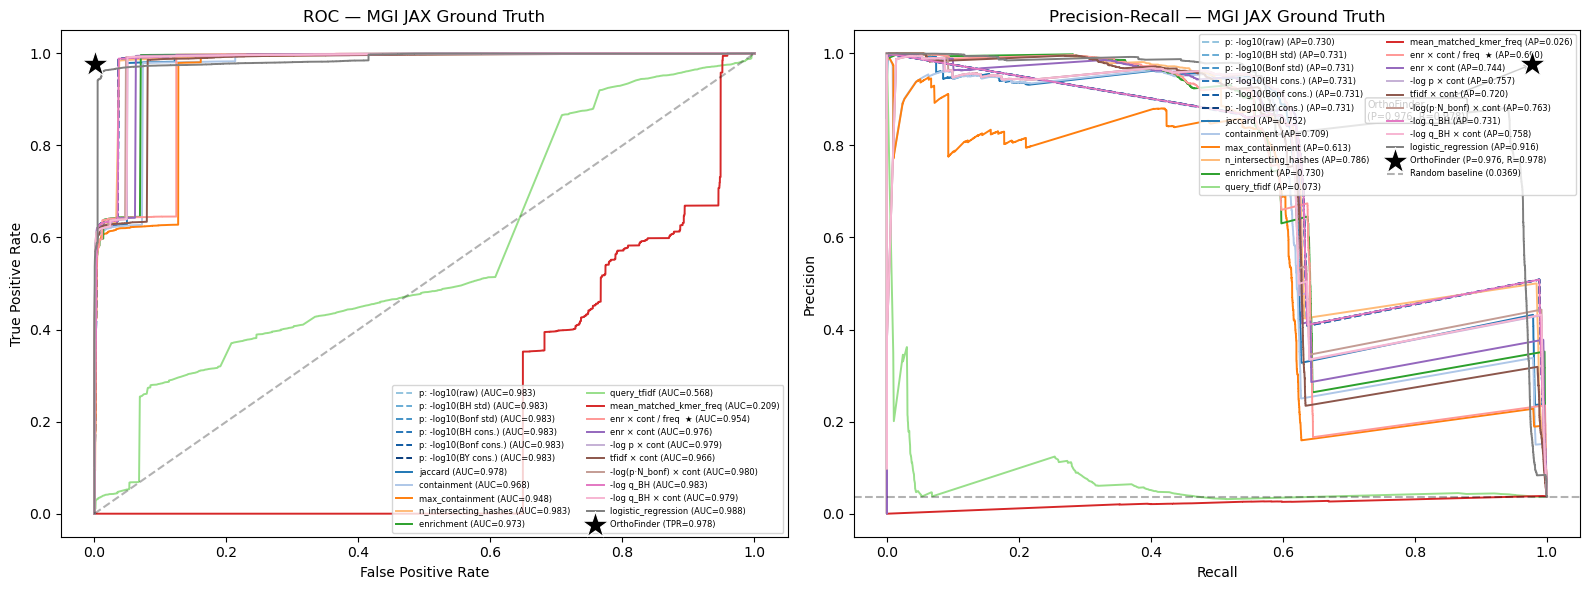

In [13]:
y_true_np = y_true.to_numpy()


def _to_np(col):
    return df[col].fill_null(0).to_numpy()


scores = {
    # --- p-value scores (higher = more significant) ---
    "p: -log10(raw)": -np.log10(df["poisson_p"].to_numpy().clip(1e-300)),
    "p: -log10(BH std)": -np.log10(df["poisson_p_bh"].to_numpy().clip(1e-300)),
    "p: -log10(Bonf std)": -np.log10(df["poisson_p_bonf"].to_numpy().clip(1e-300)),
    "p: -log10(BH cons.)": -np.log10(
        df["poisson_p_bh_conservative"].to_numpy().clip(1e-300)
    ),
    "p: -log10(Bonf cons.)": -np.log10(
        df["poisson_p_bonf_conservative"].to_numpy().clip(1e-300)
    ),
    "p: -log10(BY cons.)": -np.log10(
        df["poisson_p_by_conservative"].to_numpy().clip(1e-300)
    ),
    # --- individual kmerseek scores ---
    "jaccard": _to_np("jaccard"),
    "containment": _to_np("containment"),
    "max_containment": _to_np("max_containment"),
    "n_intersecting_hashes": _to_np("n_intersecting_hashes"),
    "enrichment": _to_np("enrichment"),
    "query_tfidf": _to_np("query_tfidf"),
    "mean_matched_kmer_freq": _to_np("mean_matched_kmer_freq"),
    # --- composite scores from ou.add_composite_scores ---
    ou.SCORE_LABELS["score_enr_cont_freq"]: _to_np("score_enr_cont_freq"),
    ou.SCORE_LABELS["score_enr_cont"]: _to_np("score_enr_cont"),
    ou.SCORE_LABELS["score_neglogp_cont"]: _to_np("score_neglogp_cont"),
    ou.SCORE_LABELS["score_tfidf_cont"]: _to_np("score_tfidf_cont"),
    ou.SCORE_LABELS["score_bonf_neglogp_cont"]: _to_np("score_bonf_neglogp_cont"),
    ou.SCORE_LABELS["score_bh_neglogq"]: _to_np("score_bh_neglogq"),
    ou.SCORE_LABELS["score_bh_neglogq_cont"]: _to_np("score_bh_neglogq_cont"),
    # --- logistic regression ---
    "logistic_regression": lr_score_full,
}

# ── ROC + PR side by side ──────────────────────────────────────────────────
# p-value scores (dashed) vs feature/composite scores (solid)
p_keys = [k for k in scores if k.startswith("p:")]
ft_keys = [k for k in scores if not k.startswith("p:")]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p_colors = plt.cm.Blues(np.linspace(0.4, 0.95, len(p_keys)))
ft_colors = plt.cm.tab20.colors  # tab20 for enough distinct colours

of_stats = confusion_stats(y_true, df["is_orthofinder"])
of_fpr = (
    of_stats["FP"] / (of_stats["FP"] + of_stats["TN"])
    if (of_stats["FP"] + of_stats["TN"]) > 0
    else 0
)

for ax_idx, (metric_fn, xlabel, title) in enumerate(
    [
        (roc_curve, "False Positive Rate", "ROC"),
        (precision_recall_curve, "Recall", "Precision-Recall"),
    ]
):
    ax = axes[ax_idx]

    for keys, colors, ls in [(p_keys, p_colors, "--"), (ft_keys, ft_colors, "-")]:
        for i, k in enumerate(keys):
            if ax_idx == 0:
                x, y_curve, _ = roc_curve(y_true_np, scores[k])
                auc_val = roc_auc_score(y_true_np, scores[k])
                ax.plot(
                    x,
                    y_curve,
                    color=colors[i % len(colors)],
                    lw=1.4,
                    ls=ls,
                    label=f"{k} (AUC={auc_val:.3f})",
                )
            else:
                prec, rec, _ = precision_recall_curve(y_true_np, scores[k])
                ap = average_precision_score(y_true_np, scores[k])
                ax.plot(
                    rec,
                    prec,
                    color=colors[i % len(colors)],
                    lw=1.4,
                    ls=ls,
                    label=f"{k} (AP={ap:.3f})",
                )

    # OrthoFinder reference point
    if ax_idx == 0:
        ax.scatter(
            [of_fpr],
            [of_stats["recall"]],
            marker="*",
            s=400,
            color="black",
            edgecolors="white",
            linewidths=0.8,
            zorder=6,
            label=f"OrthoFinder (TPR={of_stats['recall']:.3f})",
        )
        ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
        ax.set_ylabel("True Positive Rate")
    else:
        ax.scatter(
            [of_stats["recall"]],
            [of_stats["precision"]],
            marker="*",
            s=400,
            color="black",
            edgecolors="white",
            linewidths=0.8,
            zorder=6,
            label=f"OrthoFinder (P={of_stats['precision']:.3f}, R={of_stats['recall']:.3f})",
        )
        ax.annotate(
            f"OrthoFinder\n(P={of_stats['precision']:.3f}, R={of_stats['recall']:.3f})",
            xy=(of_stats["recall"], of_stats["precision"]),
            xytext=(of_stats["recall"] - 0.25, of_stats["precision"] - 0.12),
            fontsize=7,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
        )
        baseline = y_true.mean()
        ax.axhline(
            baseline,
            color="k",
            ls="--",
            alpha=0.3,
            label=f"Random baseline ({baseline:.4f})",
        )
        ax.set_ylabel("Precision")

    ax.set_xlabel(xlabel)
    ax.set_title(f"{title} — MGI JAX Ground Truth")
    ax.legend(
        fontsize=6,
        loc="lower right" if ax_idx == 0 else "upper right",
        ncol=2 if len(scores) > 8 else 1,
    )

plt.tight_layout()
plt.savefig(
    DATA_DIR / "vs_orthofinder_mgi_roc_pr.hp.k24.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 6. AUC Summary Table

In [14]:
auc_rows = []
for label, score in scores.items():
    auc_rows.append(
        {
            "Method": label,
            "AUC-ROC": roc_auc_score(y_true_np, score),
            "AUC-PR": average_precision_score(y_true_np, score),
        }
    )
auc_rows.append(
    {
        "Method": "OrthoFinder (binary)",
        "AUC-ROC": float("nan"),
        "AUC-PR": float("nan"),
    }
)

auc_df = pd.DataFrame(auc_rows)
print(
    f"Note: conservative BH/BY scores are monotone transforms of raw p, so AUC-ROC/PR are identical to raw."
)
auc_df.style.format({"AUC-ROC": "{:.4f}", "AUC-PR": "{:.4f}"}).highlight_max(
    subset=["AUC-ROC", "AUC-PR"], color="lightgreen"
)

Note: conservative BH/BY scores are monotone transforms of raw p, so AUC-ROC/PR are identical to raw.


,Method,AUC-ROC,AUC-PR
0,p: -log10(raw),0.9833,0.7298
1,p: -log10(BH std),0.9834,0.7306
2,p: -log10(Bonf std),0.9832,0.7310
3,p: -log10(BH cons.),0.9834,0.7307
4,p: -log10(Bonf cons.),0.9832,0.7310
5,p: -log10(BY cons.),0.9833,0.7308
6,jaccard,0.9785,0.7518
7,containment,0.9685,0.7090
8,max_containment,0.9482,0.6129
9,n_intersecting_hashes,0.9830,0.7856


## 7. Threshold Sweep: F1 vs p-value

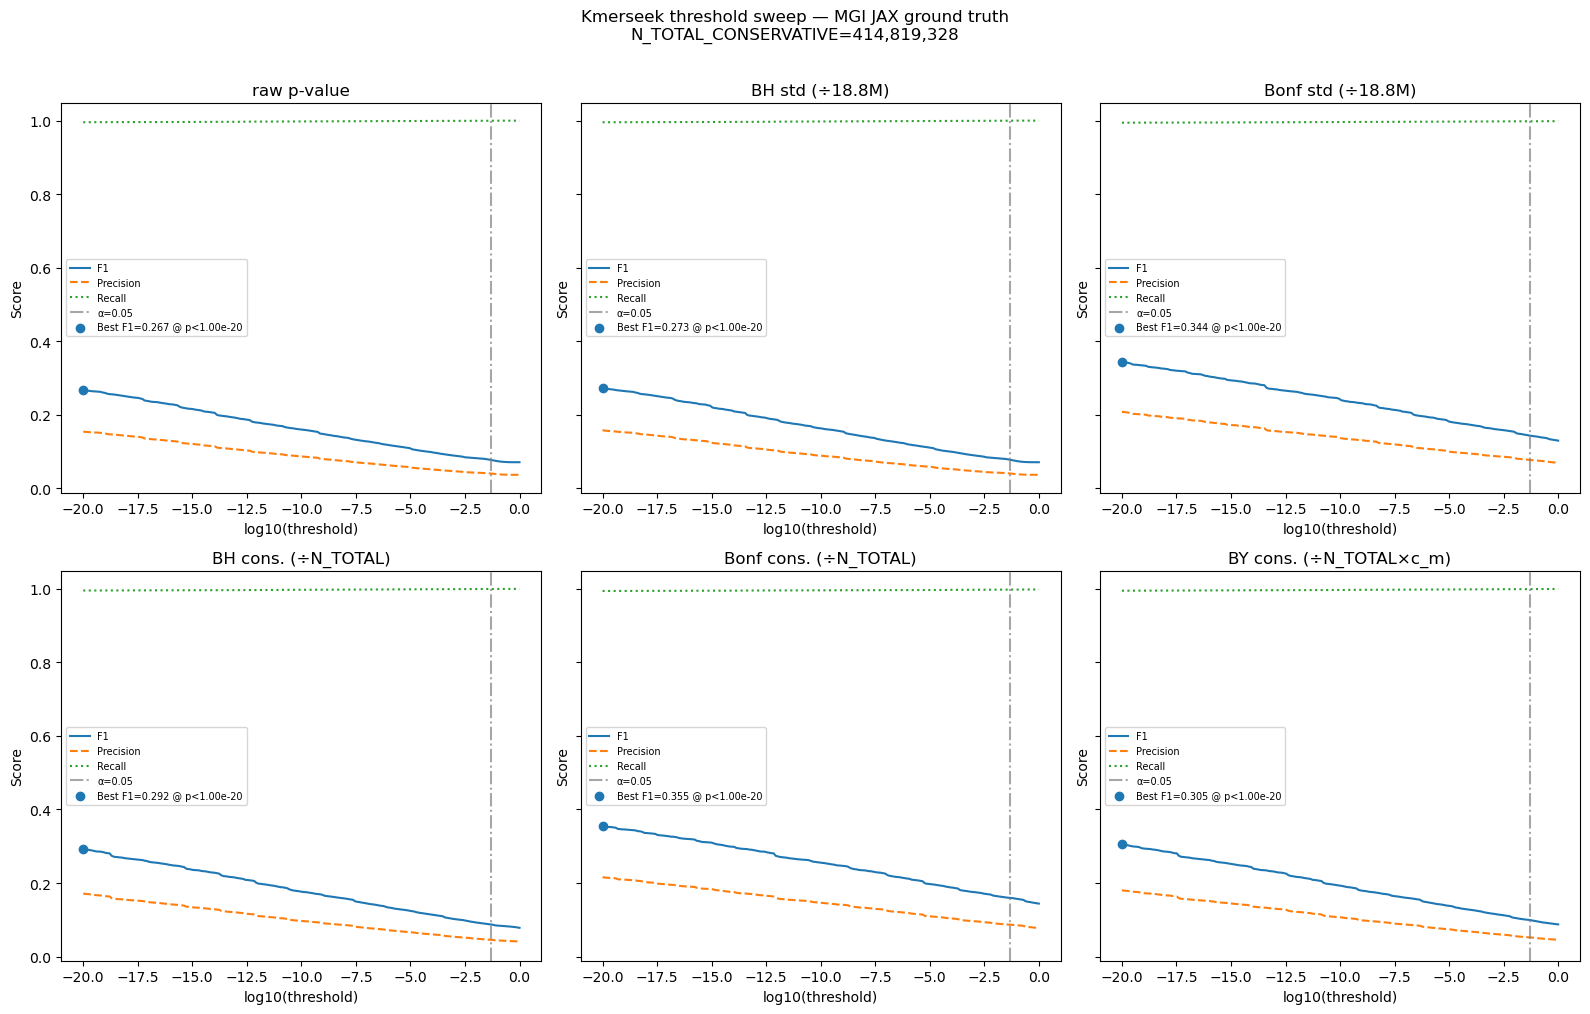

In [15]:
thresholds = np.logspace(-20, 0, 200)

sweep_cols = [
    ("poisson_p", "raw p-value"),
    ("poisson_p_bh", "BH std (÷18.8M)"),
    ("poisson_p_bonf", "Bonf std (÷18.8M)"),
    ("poisson_p_bh_conservative", "BH cons. (÷N_TOTAL)"),
    ("poisson_p_bonf_conservative", "Bonf cons. (÷N_TOTAL)"),
    ("poisson_p_by_conservative", "BY cons. (÷N_TOTAL×c_m)"),
]

ncols = 3
nrows = int(np.ceil(len(sweep_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=True)
axes = axes.flatten()

for ax, (col, label) in zip(axes, sweep_cols):
    f1s, precs, recs = [], [], []
    for t in thresholds:
        s = confusion_stats(y_true, df[col] < t)
        f1s.append(s["f1"])
        precs.append(s["precision"])
        recs.append(s["recall"])

    log_t = np.log10(thresholds)
    ax.plot(log_t, f1s, label="F1", color="C0")
    ax.plot(log_t, precs, label="Precision", color="C1", linestyle="--")
    ax.plot(log_t, recs, label="Recall", color="C2", linestyle=":")
    ax.axvline(
        np.log10(ALPHA), color="grey", linestyle="-.", alpha=0.7, label=f"α={ALPHA}"
    )

    best_idx = np.argmax(f1s)
    ax.scatter(
        [log_t[best_idx]],
        [f1s[best_idx]],
        color="C0",
        zorder=5,
        label=f"Best F1={f1s[best_idx]:.3f} @ p<{thresholds[best_idx]:.2e}",
    )

    ax.set_xlabel("log10(threshold)")
    ax.set_ylabel("Score")
    ax.set_title(label)
    ax.legend(fontsize=7)

for ax in axes[len(sweep_cols) :]:
    ax.set_visible(False)

plt.suptitle(
    f"Kmerseek threshold sweep — MGI JAX ground truth\nN_TOTAL_CONSERVATIVE={N_TOTAL_CONSERVATIVE:,}",
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "vs_orthofinder_mgi_threshold_sweep.hp.k24.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 7b. Sensitivity Until First False Positive

For each p-value correction, sort pairs by ascending p-value (most significant first) and sweep
through them in order. Plot the running recall (sensitivity) up to — but not including — the
point where the first false positive enters the predicted set.

The endpoint marker (×) shows the recall achieved just before the first FP, and the p-value at
which that FP appears. This answers: *"How many true orthologs can Kmerseek recover at 100%
precision, and how does the answer change across correction methods?"*

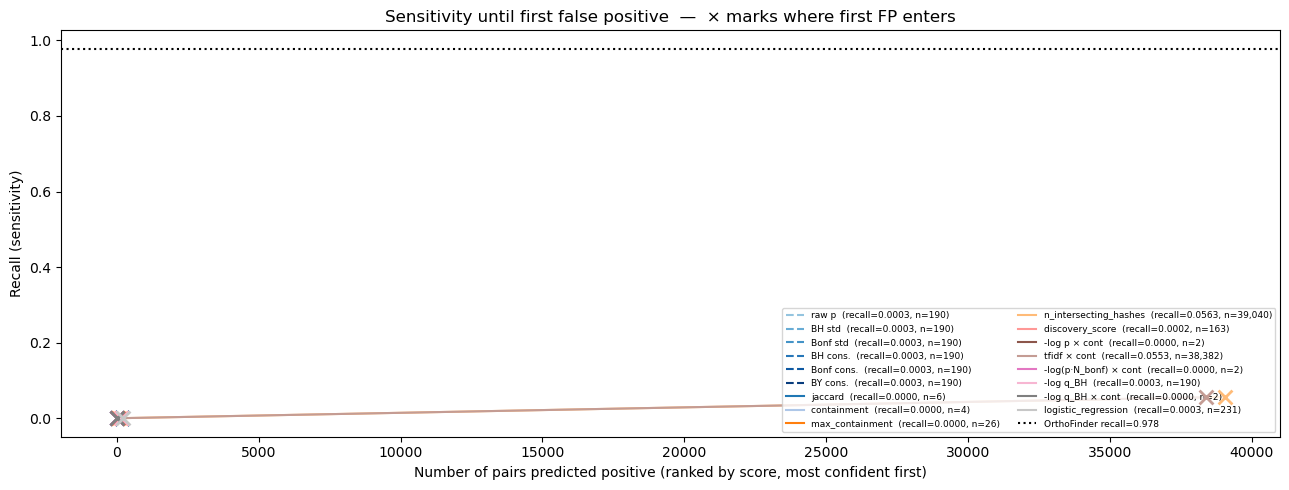

                        recall @ 0 FP  n TPs @ 0 FP  score at first FP
method                                                                
n_intersecting_hashes        0.056273         39040       1.397000e+03
tfidf × cont                 0.055325         38382       1.128034e+04
logistic_regression          0.000333           231       1.000000e+00
-log q_BH                    0.000274           190       3.000000e+02
BH std                       0.000274           190      -0.000000e+00
raw p                        0.000274           190      -0.000000e+00
BY cons.                     0.000274           190      -0.000000e+00
Bonf cons.                   0.000274           190      -0.000000e+00
BH cons.                     0.000274           190      -0.000000e+00
Bonf std                     0.000274           190      -0.000000e+00
discovery_score              0.000235           163       1.478576e+08
max_containment              0.000037            26       1.000000e+00
jaccar

In [16]:
sens_scores = {
    # p-value columns (lower = more significant, so we negate for ranking)
    "raw p": -df["poisson_p"].to_numpy(),
    "BH std": -df["poisson_p_bh"].to_numpy(),
    "Bonf std": -df["poisson_p_bonf"].to_numpy(),
    "BH cons.": -df["poisson_p_bh_conservative"].to_numpy(),
    "Bonf cons.": -df["poisson_p_bonf_conservative"].to_numpy(),
    "BY cons.": -df["poisson_p_by_conservative"].to_numpy(),
    # individual kmerseek feature scores (higher = more significant)
    "jaccard": df["jaccard"].fill_null(0).to_numpy(),
    "containment": df["containment"].fill_null(0).to_numpy(),
    "max_containment": df["max_containment"].fill_null(0).to_numpy(),
    "n_intersecting_hashes": df["n_intersecting_hashes"].fill_null(0).to_numpy(),
    "enrichment": df["enrichment"].fill_null(0).to_numpy(),
    "query_tfidf": df["query_tfidf"].fill_null(0).to_numpy(),
    "mean_matched_kmer_freq": df["mean_matched_kmer_freq"].fill_null(0).to_numpy(),
    "discovery_score": df["discovery_score"].fill_null(0).to_numpy(),
    # composite scores from ou.add_composite_scores
    ou.SCORE_LABELS["score_enr_cont_freq"]: df["score_enr_cont_freq"]
    .fill_null(0)
    .to_numpy(),
    ou.SCORE_LABELS["score_enr_cont"]: df["score_enr_cont"].fill_null(0).to_numpy(),
    ou.SCORE_LABELS["score_neglogp_cont"]: df["score_neglogp_cont"]
    .fill_null(0)
    .to_numpy(),
    ou.SCORE_LABELS["score_tfidf_cont"]: df["score_tfidf_cont"].fill_null(0).to_numpy(),
    ou.SCORE_LABELS["score_bonf_neglogp_cont"]: df["score_bonf_neglogp_cont"]
    .fill_null(0)
    .to_numpy(),
    ou.SCORE_LABELS["score_bh_neglogq"]: df["score_bh_neglogq"].fill_null(0).to_numpy(),
    ou.SCORE_LABELS["score_bh_neglogq_cont"]: df["score_bh_neglogq_cont"]
    .fill_null(0)
    .to_numpy(),
    "logistic_regression": lr_score_full,
}

is_tp_all = y_true.to_numpy().astype(bool)
total_pos = is_tp_all.sum()

fig, ax = plt.subplots(figsize=(13, 5))
p_colors = plt.cm.Blues(np.linspace(0.4, 0.95, 6))
ft_colors = list(plt.cm.tab20.colors)

_P_KEYS = {"raw p", "BH std", "Bonf std", "BH cons.", "Bonf cons.", "BY cons."}
_p_list = [k for k in sens_scores if k in _P_KEYS]
_ft_list = [k for k in sens_scores if k not in _P_KEYS]

summary_rows = []
for i, (label, score) in enumerate(sens_scores.items()):
    is_pval = label in _P_KEYS
    color_idx = _p_list.index(label) if is_pval else _ft_list.index(label)
    color = p_colors[color_idx] if is_pval else ft_colors[color_idx % len(ft_colors)]
    ls = "--" if is_pval else "-"

    order = np.argsort(-score, kind="stable")  # descending: most significant first
    p_sorted = score[order]
    tp_sorted = is_tp_all[order]

    cum_tp = np.cumsum(tp_sorted)
    cum_fp = np.cumsum(~tp_sorted)

    first_fp_idx = int(np.argmax(cum_fp >= 1))

    if first_fp_idx == 0:
        max_recall_no_fp = 0.0
        score_at_first_fp = p_sorted[0]
    else:
        max_recall_no_fp = cum_tp[first_fp_idx - 1] / total_pos
        score_at_first_fp = p_sorted[first_fp_idx]

    summary_rows.append(
        {
            "method": label,
            "recall @ 0 FP": max_recall_no_fp,
            "n TPs @ 0 FP": int(cum_tp[max(first_fp_idx - 1, 0)]),
            "score at first FP": score_at_first_fp,
        }
    )

    idx_range = np.arange(first_fp_idx)
    if len(idx_range) > 5000:
        keep = np.unique(np.linspace(0, len(idx_range) - 1, 5000).astype(int))
        idx_range = idx_range[keep]

    if len(idx_range) > 0:
        ax.plot(
            idx_range,
            cum_tp[idx_range] / total_pos,
            color=color,
            ls=ls,
            lw=1.5,
            label=f"{label}  (recall={max_recall_no_fp:.4f}, n={first_fp_idx:,})",
        )
        ax.scatter(
            [first_fp_idx],
            [max_recall_no_fp],
            color=color,
            marker="x",
            s=100,
            linewidths=2,
            zorder=6,
        )

of_recall = of_stats["recall"]
ax.axhline(
    of_recall,
    color="black",
    ls=":",
    lw=1.5,
    label=f"OrthoFinder recall={of_recall:.3f}",
)

ax.set_xlabel(
    "Number of pairs predicted positive (ranked by score, most confident first)"
)
ax.set_ylabel("Recall (sensitivity)")
ax.set_title("Sensitivity until first false positive  —  × marks where first FP enters")
ax.legend(fontsize=6.5, loc="lower right", ncol=2)
fig.tight_layout()
plt.savefig(
    DATA_DIR / "vs_orthofinder_mgi_sensitivity_until_first_fp.hp.k24.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

summary_df = pd.DataFrame(summary_rows).set_index("method")
print(summary_df.sort_values("recall @ 0 FP", ascending=False).to_string())

## 7c. Per-Query Sensitivity Until First FP (ROCX-style)

Mirrors the SCOPe benchmark in notebook 065.  For **each human query protein** with ≥1 true
MGI ortholog, rank all mouse hits by score (most significant first) and record the fraction of
true orthologs recovered before the first false positive enters the ranked list.

- x-axis: fraction of query proteins (sorted from lowest → highest per-query sensitivity)
- y-axis: per-query sensitivity (fraction of true orthologs recovered before first FP)
- AUC = area under this curve = average per-query sensitivity

The **conservative Bonferroni threshold** (N\_TOTAL = N\_HUMAN × N\_MOUSE ≈ 415 M, from
notebook 120) is used as the primary Kmerseek significance criterion.

Computing per-query sensitivities (may take ~1–2 min) …
  raw p-value: 16,637 queries
  Bonf cons. (primary): 16,637 queries
  BH std: 16,637 queries
  jaccard: 16,637 queries
  n_intersecting_hashes: 16,637 queries
  enrichment: 16,637 queries
  enr × cont / freq  ★: 16,637 queries
  -log p × cont: 16,637 queries
  -log(p·N_bonf) × cont: 16,637 queries
  -log q_BH × cont: 16,637 queries
  logistic_regression: 16,637 queries
OrthoFinder per-query recall: 16,637 queries with ≥1 TP


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_86003/2897951058.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(sorted_sens, frac))
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_86003/2897951058.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  of_auc    = float(np.trapz(of_sorted, of_frac))


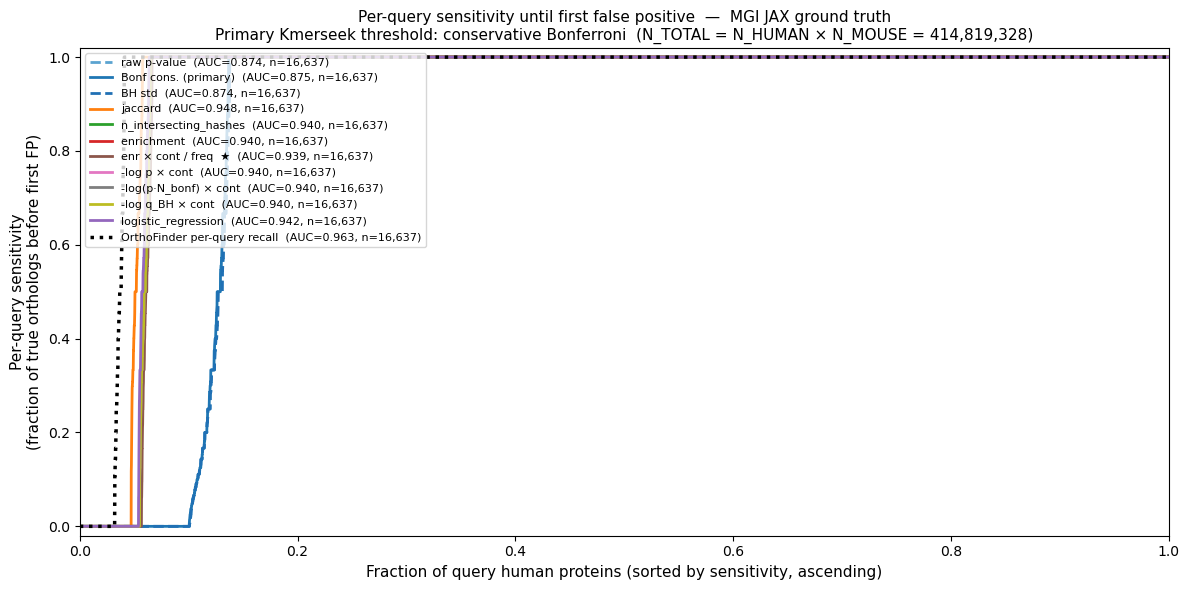

,n_queries,mean_sensitivity,median_sensitivity,frac_perfect (=1.0),frac_zero (=0.0)
method,,,,,
raw p-value,16637,0.874,1.000,0.862,0.101
Bonf cons. (primary),16637,0.875,1.000,0.863,0.100
BH std,16637,0.874,1.000,0.862,0.101
jaccard,16637,0.948,1.000,0.942,0.047
n_intersecting_hashes,16637,0.940,1.000,0.935,0.055
enrichment,16637,0.940,1.000,0.935,0.055
enr × cont / freq ★,16637,0.939,1.000,0.934,0.057
-log p × cont,16637,0.940,1.000,0.935,0.055
-log(p·N_bonf) × cont,16637,0.940,1.000,0.935,0.055


In [17]:
def compute_per_query_sensitivity(
    df_in,
    score_arr,
    ascending_score=True,
    gt_col="is_mgi_ortholog",
    query_col="query_name",
):
    """
    For each query protein with ≥1 true ortholog, compute the fraction of true
    orthologs recovered before the first false positive (sensitivity until first FP).

    Parameters
    ----------
    df_in : polars DataFrame containing query_col and gt_col columns
    score_arr : numpy array of scores (same row order as df_in)
    ascending_score : True if lower score = more significant (e.g., p-values)
    gt_col : ground truth column (True = positive / ortholog)
    query_col : column identifying the query protein

    Returns
    -------
    numpy array of per-query sensitivities (one value per query with ≥1 TP)
    """
    work = df_in.select([query_col, gt_col]).with_columns(
        [
            pl.Series("_score", score_arr),
            (~pl.col(gt_col)).alias("_is_fp"),
            pl.col(gt_col).alias("_is_tp"),
        ]
    )

    work_sorted = work.sort(
        [query_col, "_score"],
        descending=[False, not ascending_score],
    )

    work_cum = work_sorted.with_columns(
        [
            pl.col("_is_fp").cast(pl.Int32).cum_sum().over(query_col).alias("_cum_fp"),
            pl.col("_is_tp").cast(pl.Int32).cum_sum().over(query_col).alias("_cum_tp"),
            pl.col("_is_tp").cast(pl.Int32).sum().over(query_col).alias("_total_tp"),
        ]
    )

    from_before_fp = (
        work_cum.filter(pl.col("_cum_fp") == 0)
        .group_by(query_col)
        .agg(pl.col("_cum_tp").max().alias("n_tp_before_fp"))
    )

    all_pos = (
        work_cum.filter(pl.col("_total_tp") > 0)
        .group_by(query_col)
        .agg(pl.col("_total_tp").first())
    )

    per_query = (
        all_pos.join(from_before_fp, on=query_col, how="left")
        .with_columns(pl.col("n_tp_before_fp").fill_null(0))
        .with_columns(
            (pl.col("n_tp_before_fp") / pl.col("_total_tp")).alias("sensitivity")
        )
    )
    return per_query["sensitivity"].to_numpy()


def rocx_curve_plot(ax, sens_arr, label, color, ls="-", lw=2.0):
    """Plot one ROCX-style sensitivity curve and return its AUC."""
    sorted_sens = np.sort(sens_arr)
    frac = np.linspace(0, 1, len(sorted_sens))
    auc = float(np.trapz(sorted_sens, frac))
    ax.plot(
        frac,
        sorted_sens,
        color=color,
        ls=ls,
        lw=lw,
        label=f"{label}  (AUC={auc:.3f}, n={len(sorted_sens):,})",
    )
    return auc


# ── Scoring methods to evaluate ────────────────────────────────────────────
# (label, df_col, ascending_score, color, linestyle)
# ascending=True  → lower score is more significant (p-values)
# ascending=False → higher score is more significant (feature / composite scores)
# df_col=None     → use lr_score_full directly
per_query_configs = [
    ("raw p-value", "poisson_p", True, plt.cm.Blues(0.55), "--"),
    ("Bonf cons. (primary)", "poisson_p_bonf_conservative", True, "C0", "-"),
    ("BH std", "poisson_p_bh", True, plt.cm.Blues(0.75), "--"),
    ("jaccard", "jaccard", False, "C1", "-"),
    ("n_intersecting_hashes", "n_intersecting_hashes", False, "C2", "-"),
    ("enrichment", "enrichment", False, "C3", "-"),
    # composite scores from ou.add_composite_scores
    (ou.SCORE_LABELS["score_enr_cont_freq"], "score_enr_cont_freq", False, "C5", "-"),
    (ou.SCORE_LABELS["score_neglogp_cont"], "score_neglogp_cont", False, "C6", "-"),
    (
        ou.SCORE_LABELS["score_bonf_neglogp_cont"],
        "score_bonf_neglogp_cont",
        False,
        "C7",
        "-",
    ),
    (
        ou.SCORE_LABELS["score_bh_neglogq_cont"],
        "score_bh_neglogq_cont",
        False,
        "C8",
        "-",
    ),
    ("logistic_regression", None, False, "C4", "-"),
]

print("Computing per-query sensitivities (may take ~1–2 min) …")
pq_results = {}
for label, col, asc, color, ls in per_query_configs:
    score_arr = lr_score_full if col is None else df[col].fill_null(0).to_numpy()
    pq_results[label] = (
        compute_per_query_sensitivity(df, score_arr, ascending_score=asc),
        color,
        ls,
    )
    print(f"  {label}: {len(pq_results[label][0]):,} queries")

# ── OrthoFinder per-query recall ───────────────────────────────────────────
of_per_query_df = (
    df.filter(pl.col("is_mgi_ortholog"))
    .group_by("query_name")
    .agg(
        [
            pl.col("is_mgi_ortholog").sum().alias("total_tp"),
            pl.col("is_orthofinder").sum().alias("n_tp_of"),
        ]
    )
    .with_columns((pl.col("n_tp_of") / pl.col("total_tp")).alias("of_recall"))
)
of_per_query_sens = of_per_query_df["of_recall"].to_numpy()
print(f"OrthoFinder per-query recall: {len(of_per_query_sens):,} queries with ≥1 TP")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for label, (sens_arr, color, ls) in pq_results.items():
    rocx_curve_plot(ax, sens_arr, label, color, ls)

of_sorted = np.sort(of_per_query_sens)
of_frac = np.linspace(0, 1, len(of_sorted))
of_auc = float(np.trapz(of_sorted, of_frac))
ax.plot(
    of_frac,
    of_sorted,
    color="black",
    ls=":",
    lw=2.5,
    label=f"OrthoFinder per-query recall  (AUC={of_auc:.3f}, n={len(of_sorted):,})",
)

ax.set_xlabel(
    "Fraction of query human proteins (sorted by sensitivity, ascending)", fontsize=11
)
ax.set_ylabel(
    "Per-query sensitivity\n(fraction of true orthologs before first FP)", fontsize=11
)
ax.set_title(
    "Per-query sensitivity until first false positive  —  MGI JAX ground truth\n"
    f"Primary Kmerseek threshold: conservative Bonferroni  "
    f"(N_TOTAL = N_HUMAN × N_MOUSE = {N_TOTAL_CONSERVATIVE:,})",
    fontsize=11,
)
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.savefig(
    DATA_DIR / "vs_orthofinder_mgi_per_query_sensitivity.hp.k24.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
pq_summary = []
for label, (sens_arr, *_) in pq_results.items():
    pq_summary.append(
        {
            "method": label,
            "n_queries": len(sens_arr),
            "mean_sensitivity": float(sens_arr.mean()),
            "median_sensitivity": float(np.median(sens_arr)),
            "frac_perfect (=1.0)": float((sens_arr == 1.0).mean()),
            "frac_zero (=0.0)": float((sens_arr == 0.0).mean()),
        }
    )
pq_summary.append(
    {
        "method": "OrthoFinder (per-query recall)",
        "n_queries": len(of_per_query_sens),
        "mean_sensitivity": float(of_per_query_sens.mean()),
        "median_sensitivity": float(np.median(of_per_query_sens)),
        "frac_perfect (=1.0)": float((of_per_query_sens == 1.0).mean()),
        "frac_zero (=0.0)": float((of_per_query_sens == 0.0).mean()),
    }
)

pq_summary_df = pd.DataFrame(pq_summary).set_index("method")
pq_summary_df.style.format(
    {
        "mean_sensitivity": "{:.3f}",
        "median_sensitivity": "{:.3f}",
        "frac_perfect (=1.0)": "{:.3f}",
        "frac_zero (=0.0)": "{:.3f}",
    }
)

## 8. Ensembl vs MGI Ground Truth Comparison

How much do the two ground truths agree?

In [18]:
gt_cross = (
    df.with_columns(
        [
            pl.when(pl.col("is_ortholog"))
            .then(pl.lit("Ensembl ortholog"))
            .otherwise(pl.lit("Ensembl non-ortholog"))
            .alias("ensembl_gt"),
            pl.when(pl.col("is_mgi_ortholog"))
            .then(pl.lit("MGI ortholog"))
            .otherwise(pl.lit("MGI non-ortholog"))
            .alias("mgi_gt"),
        ]
    )
    .group_by(["ensembl_gt", "mgi_gt"])
    .agg(pl.len().alias("count"))
    .sort(["ensembl_gt", "mgi_gt"])
)
print("Ground truth agreement:")
print(gt_cross)

Ground truth agreement:
shape: (2, 3)
┌──────────────────────┬──────────────────┬──────────┐
│ ensembl_gt           ┆ mgi_gt           ┆ count    │
│ ---                  ┆ ---              ┆ ---      │
│ str                  ┆ str              ┆ u32      │
╞══════════════════════╪══════════════════╪══════════╡
│ Ensembl non-ortholog ┆ MGI non-ortholog ┆ 18110040 │
│ Ensembl ortholog     ┆ MGI ortholog     ┆ 693759   │
└──────────────────────┴──────────────────┴──────────┘


In [19]:
y_ensembl = df["is_ortholog"]

rows = []
for gt_label, y_gt in [("MGI JAX", y_true), ("Ensembl", y_ensembl)]:
    for name, y_pred in predictions.items():
        s = confusion_stats(y_gt, y_pred)
        rows.append(
            {
                "ground_truth": gt_label,
                "method": name,
                "precision": s["precision"],
                "recall": s["recall"],
                "f1": s["f1"],
            }
        )

compare_df = pd.DataFrame(rows).pivot(
    index="method", columns="ground_truth", values=["precision", "recall", "f1"]
)
compare_df.style.format("{:.3f}")

## 9. Resource Usage

In [20]:
def parse_log_times(log_path: Path) -> dict:
    """Extract start time, end time, wall time, and peak memory from a kmerseek log."""
    with gzip.open(log_path, "rt") as f:
        content = f.read()

    start = re.search(r"Start time: (\S+ \S+)", content)
    end = re.search(r"End time: (\S+ \S+)", content)
    wall = re.search(r"([\d.]+) real", content)
    peak_mem = re.search(r"([\d]+)  peak memory footprint", content)
    max_rss = re.search(r"([\d]+)  maximum resident set size", content)

    result = {"log": log_path.name}
    if start and end:
        t0 = datetime.strptime(start.group(1), "%Y-%m-%d %H:%M:%S")
        t1 = datetime.strptime(end.group(1), "%Y-%m-%d %H:%M:%S")
        result["start"] = t0
        result["end"] = t1
        result["wall_s"] = (t1 - t0).total_seconds()
    if wall:
        result["wall_s"] = float(
            wall.group(1)
        )  # override with precise value if available
    if peak_mem:
        result["peak_mem_gb"] = int(peak_mem.group(1)) / 1e9
    if max_rss:
        result["max_rss_gb"] = int(max_rss.group(1)) / 1e9
    return result


search_info = parse_log_times(KMERSEEK_SEARCH_LOG)
mouse_index_info = parse_log_times(MOUSE_INDEX_LOG)

# Human index only available up to k22; extrapolate or note N/A
human_index_wall_s = None
if HUMAN_INDEX_LOG.exists():
    human_index_info = parse_log_times(HUMAN_INDEX_LOG)
    human_index_wall_s = human_index_info.get("wall_s")

kmerseek_total_s = (
    search_info.get("wall_s", 0)
    + mouse_index_info.get("wall_s", 0)
    + (human_index_wall_s or 0)
)

orthofinder_total_s = 6107.058459  # from OrthoFinder output (2026-03-03)

resource_rows = [
    {
        "Tool": "Kmerseek (HP k=24)",
        "Step": "Index human proteome",
        "Wall time (s)": human_index_wall_s,
        "Peak mem (GB)": (
            human_index_info.get("peak_mem_gb") if HUMAN_INDEX_LOG.exists() else None
        ),
    },
    {
        "Tool": "Kmerseek (HP k=24)",
        "Step": "Index mouse proteome",
        "Wall time (s)": mouse_index_info.get("wall_s"),
        "Peak mem (GB)": mouse_index_info.get("peak_mem_gb"),
    },
    {
        "Tool": "Kmerseek (HP k=24)",
        "Step": "Search human vs mouse",
        "Wall time (s)": search_info.get("wall_s"),
        "Peak mem (GB)": search_info.get("max_rss_gb"),
    },
    {
        "Tool": "Kmerseek (HP k=24)",
        "Step": "TOTAL",
        "Wall time (s)": kmerseek_total_s if kmerseek_total_s > 0 else None,
        "Peak mem (GB)": None,
    },
    {
        "Tool": "OrthoFinder v3.1.0",
        "Step": "TOTAL (DIAMOND + MCL + trees)",
        "Wall time (s)": orthofinder_total_s,
        "Peak mem (GB)": None,
    },
]

resource_df = pd.DataFrame(resource_rows)
resource_df["Wall time (min)"] = resource_df["Wall time (s)"] / 60
resource_df["Wall time (hr)"] = resource_df["Wall time (min)"] / 60
resource_df[
    [
        "Tool",
        "Step",
        "Wall time (s)",
        "Wall time (min)",
        "Wall time (hr)",
        "Peak mem (GB)",
    ]
].style.format(
    {
        "Wall time (s)": "{:.1f}",
        "Wall time (min)": "{:.1f}",
        "Wall time (hr)": "{:.2f}",
        "Peak mem (GB)": "{:.1f}",
    }
)

,Tool,Step,Wall time (s),Wall time (min),Wall time (hr),Peak mem (GB)
0,Kmerseek (HP k=24),Index human proteome,nan,nan,nan,nan
1,Kmerseek (HP k=24),Index mouse proteome,3473.3,57.9,0.96,19.2
2,Kmerseek (HP k=24),Search human vs mouse,80.0,1.3,0.02,18.9
3,Kmerseek (HP k=24),TOTAL,3553.2,59.2,0.99,nan
4,OrthoFinder v3.1.0,TOTAL (DIAMOND + MCL + trees),6107.1,101.8,1.70,nan


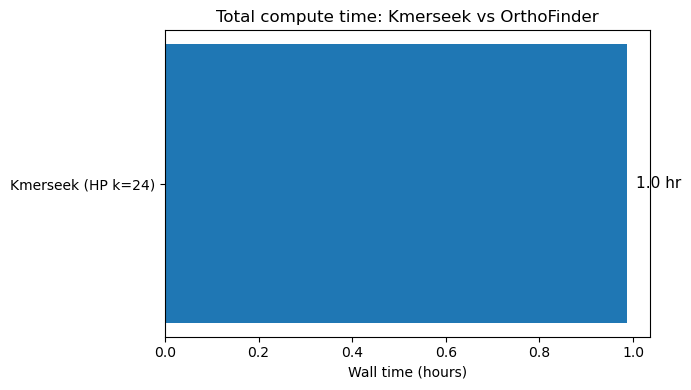

In [21]:
# Summary bar chart
total_rows = resource_df[resource_df["Step"] == "TOTAL"].copy()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    total_rows["Tool"],
    total_rows["Wall time (s)"] / 3600,
    color=["C0", "C1"],
)
for bar, val in zip(bars, total_rows["Wall time (s)"]):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val/3600:.1f} hr",
        va="center",
        fontsize=11,
    )
ax.set_xlabel("Wall time (hours)")
ax.set_title("Total compute time: Kmerseek vs OrthoFinder")
plt.tight_layout()
plt.savefig(
    DATA_DIR / "vs_orthofinder_mgi_resource_time.hp.k24.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 10. Summary

Print a concise comparison table.

In [22]:
print("=" * 70)
print("KMERSEEK vs ORTHOFINDER — MGI JAX Ground Truth (HP k=24, full data)")
print("=" * 70)
print(f"Total pairs evaluated : {len(df):,}")
print(f"MGI ortholog pairs    : {int(y_true.sum()):,} ({y_true.mean()*100:.2f}%)")
print()
print(stats.to_string(float_format="{:.3f}".format))
print()
print("AUC (continuous scores):")
print(auc_df.to_string(index=False, float_format="{:.4f}".format))
print()
print("Wall time:")
for _, r in total_rows.iterrows():
    if pd.notna(r["Wall time (s)"]):
        print(
            f"  {r['Tool']}: {r['Wall time (s)']/3600:.2f} hr ({r['Wall time (s)']:.0f} s)"
        )
print("=" * 70)

KMERSEEK vs ORTHOFINDER — MGI JAX Ground Truth (HP k=24, full data)
Total pairs evaluated : 18,803,799
MGI ortholog pairs    : 693,759 (3.69%)

                            n_predicted      TP        FP      FN        TN  precision  recall    f1
method                                                                                              
kmerseek_pval (raw)            17274679  693736  16580943      23   1529097      0.040   1.000 0.077
kmerseek_pval_bh (std)         17169044  693735  16475309      24   1634731      0.040   1.000 0.078
kmerseek_pval_bonf (std)        8966207  692598   8273609    1161   9836431      0.077   0.998 0.143
kmerseek_bonf_conservative      7984952  692343   7292609    1416  10817431      0.087   0.998 0.160
kmerseek_bh_conservative       15183276  693492  14489784     267   3620256      0.046   1.000 0.087
kmerseek_by_conservative       13244379  693282  12551097     477   5558943      0.052   0.999 0.099
kmerseek_jaccard>0.0487          610996  429977 